In [1]:
# Problem Statement : Predict House Price In Bhubaneswar

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
house_df = pd.read_csv('house_prices_bhubaneswar.csv')

In [4]:
house_df

,House_ID,Size_sqft,Bedrooms,Location_Score,Age_years,Price_Lakhs
0,1,1200,2,8,5,55
1,2,1500,3,9,3,75
2,3,900,2,6,10,38
3,4,2000,4,9,2,95
4,5,1800,3,7,4,80
5,6,1100,2,5,8,42
6,7,2200,4,10,1,110
7,8,1600,3,8,5,78
8,9,1400,3,6,6,60
9,10,1000,2,5,12,35


In [5]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   House_ID        10 non-null     int64
 1   Size_sqft       10 non-null     int64
 2   Bedrooms        10 non-null     int64
 3   Location_Score  10 non-null     int64
 4   Age_years       10 non-null     int64
 5   Price_Lakhs     10 non-null     int64
dtypes: int64(6)
memory usage: 612.0 bytes


In [6]:
house_df.describe()

,House_ID,Size_sqft,Bedrooms,Location_Score,Age_years,Price_Lakhs
count,10.00000,10.000000,10.000000,10.000000,10.00000,10.000000
mean,5.50000,1470.000000,2.800000,7.300000,5.60000,66.800000
std,3.02765,434.741302,0.788811,1.766981,3.50238,25.098915
min,1.00000,900.000000,2.000000,5.000000,1.00000,35.000000
25%,3.25000,1125.000000,2.000000,6.000000,3.25000,45.250000
50%,5.50000,1450.000000,3.000000,7.500000,5.00000,67.500000
75%,7.75000,1750.000000,3.000000,8.750000,7.50000,79.500000
max,10.00000,2200.000000,4.000000,10.000000,12.00000,110.000000


In [9]:
X = house_df.drop('Price_Lakhs', axis=1)
y = house_df['Price_Lakhs']
X

,House_ID,Size_sqft,Bedrooms,Location_Score,Age_years
0,1,1200,2,8,5
1,2,1500,3,9,3
2,3,900,2,6,10
3,4,2000,4,9,2
4,5,1800,3,7,4
5,6,1100,2,5,8
6,7,2200,4,10,1
7,8,1600,3,8,5
8,9,1400,3,6,6
9,10,1000,2,5,12


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [13]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred = model.predict(X_test)

In [19]:
X_test

,House_ID,Size_sqft,Bedrooms,Location_Score,Age_years
2,3,900,2,6,10
9,10,1000,2,5,12
6,7,2200,4,10,1


In [20]:
house_df

,House_ID,Size_sqft,Bedrooms,Location_Score,Age_years,Price_Lakhs
0,1,1200,2,8,5,55
1,2,1500,3,9,3,75
2,3,900,2,6,10,38
3,4,2000,4,9,2,95
4,5,1800,3,7,4,80
5,6,1100,2,5,8,42
6,7,2200,4,10,1,110
7,8,1600,3,8,5,78
8,9,1400,3,6,6,60
9,10,1000,2,5,12,35


In [22]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.9898773411516886

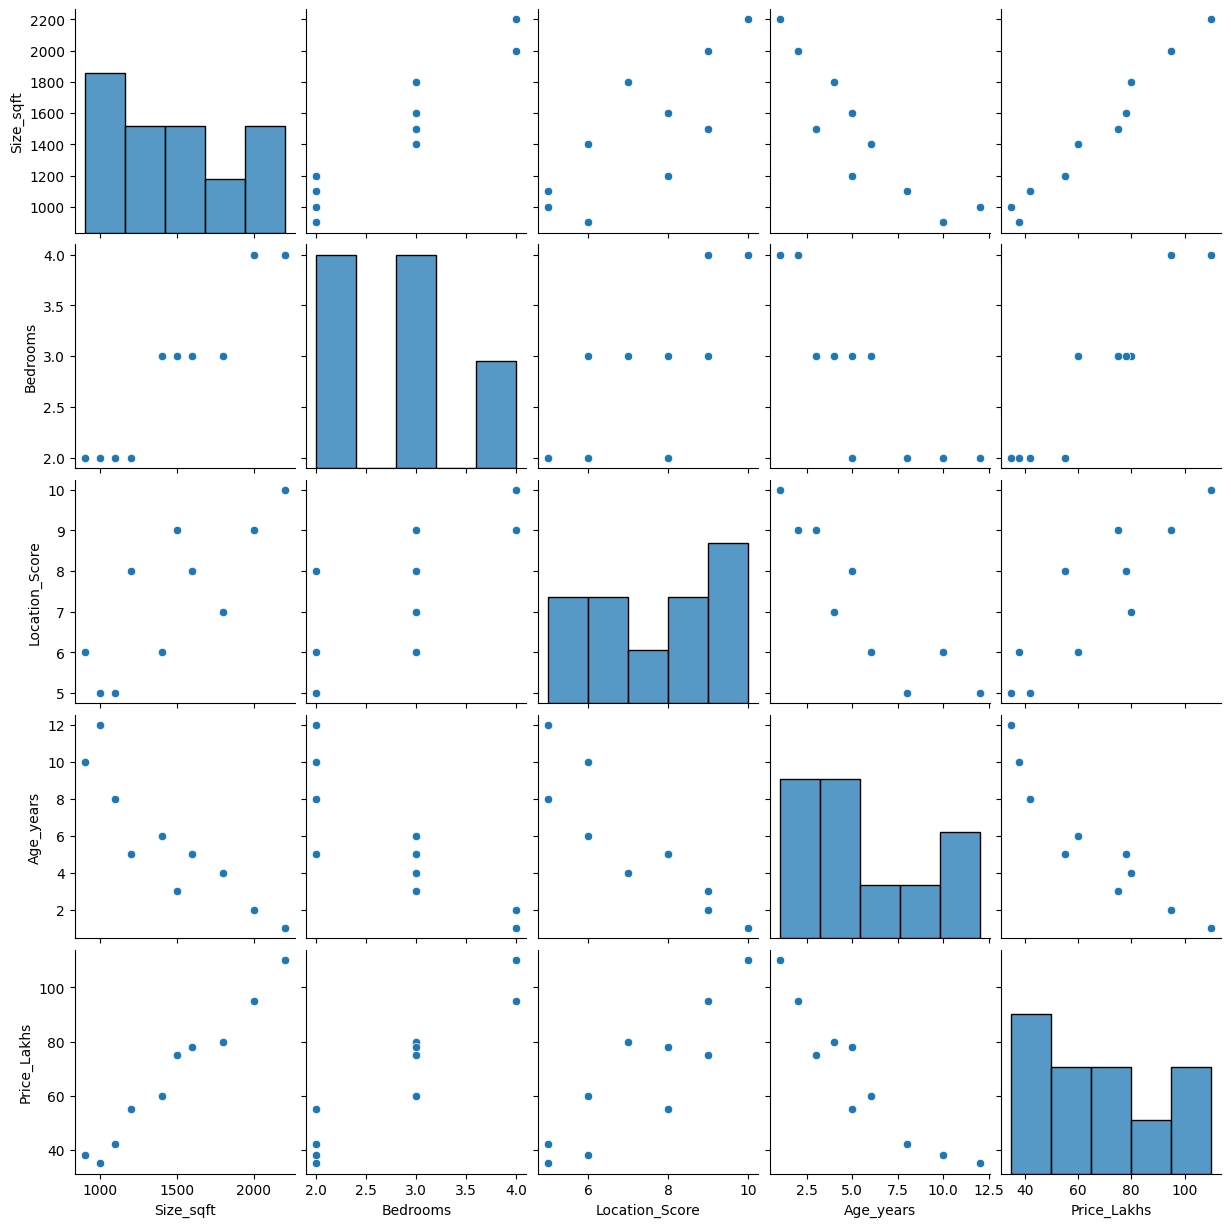

In [24]:
sns.pairplot(house_df.drop('House_ID', axis=1))
plt.show()


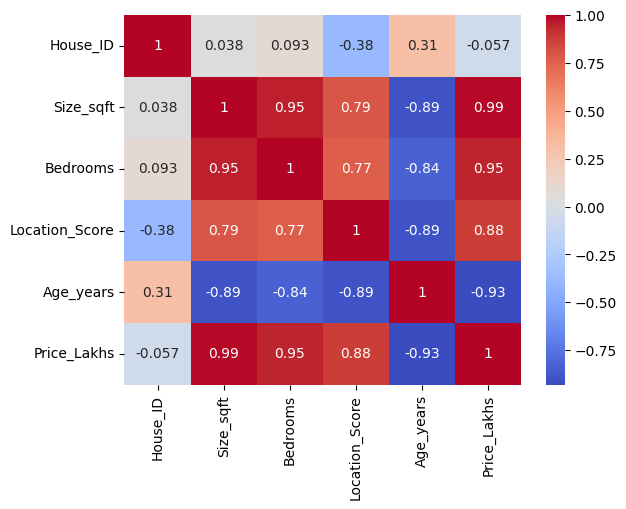

In [25]:
sns.heatmap(house_df.corr(), annot=True, cmap="coolwarm")
plt.show()


In [26]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)


Intercept: -23.860335195532116
Coefficients: [ 0.91806331  0.04247672 -1.86964618  4.39851024 -0.65735568]
          Feature  Coefficient
0        House_ID     0.918063
1       Size_sqft     0.042477
2        Bedrooms    -1.869646
3  Location_Score     4.398510
4       Age_years    -0.657356
